In [1]:
import torch
import netCDF4 as nc
import numpy as np
import torch
from time import perf_counter
import os
from unbalancedsinkhorn import DebiasedUOT

import matplotlib.pyplot as plt


# Illustration for irregular/different grids

Cell areas are taken into account simply by taking our mm acumulation values and multiplying by the cell areas - creating a volumen which we then transport.

The examples are slightly contrived, in that I take out the cell area from the guasisna density to then add it back in for illustration purposes. For real accumulations, the mm is already accounting for the averagin over cell area. 

Preciosuly, we assumed that the input grid was regular enough so that areas can be scaled out, also as both grids have been the same this scaled out. For different grids we need to take into account the different cell areas.

#### EX1: Simple point clouds on different regular grids

If both grids are regular but different, we can still use tensorisation. So consdier if interpolation onto a close high resolution, regular, grid is an option - as tensorisation provides signifcant computational advantage.

In [2]:

def multimodal_gaussian_2d(means, stds, N=100, domain=[-1, 1, -1, 1], amplitudes=None, M=None):
    """
    Generate a multimodal 2D Gaussian field on an N×N mesh.

    Parameters
    ----------
    means : list of (mx, my)
        Mean of each Gaussian mode.
    stds : list of (sx, sy)
        Standard deviations for each mode.
    N : int
        Mesh size (N × N).
    domain : [xmin, xmax, ymin, ymax]
        Spatial domain to generate the mesh.
    amplitudes : list or None
        Optional amplitude per mode. Defaults to 1 for each mode.

    Returns
    -------
    density : (N, N) numpy array
        The multimodal Gaussian field (not normalized globally).
    mesh : (X, Y) tuple
        Meshgrid coordinates.
    """

    # unpack domain
    xmin, xmax, ymin, ymax = domain

    if M is None:
        M=N
    
    # create regular N×N grid
    x = np.linspace(xmin, xmax, N)
    y = np.linspace(ymin, ymax, M)
    X, Y = np.meshgrid(x, y, indexing='ij')
    cell_areas = ((xmax - xmin) / (N)) * ((ymax - ymin) / (M)) # approximatly as we've not centred.

    # initialize result
    density = np.zeros((N, M))
    # default amplitudes = 1
    if amplitudes is None:
        amplitudes = [1.0] * len(means)

    # build the multimodal gaussian
    for (mx, my), (sx, sy), A in zip(means, stds, amplitudes):
        gaussian = A * np.exp(-(((X - mx)**2) / (2 * sx**2) + ((Y - my)**2) / (2 * sy**2)))
        density += gaussian

    return density, (X, Y), (x, y), cell_areas


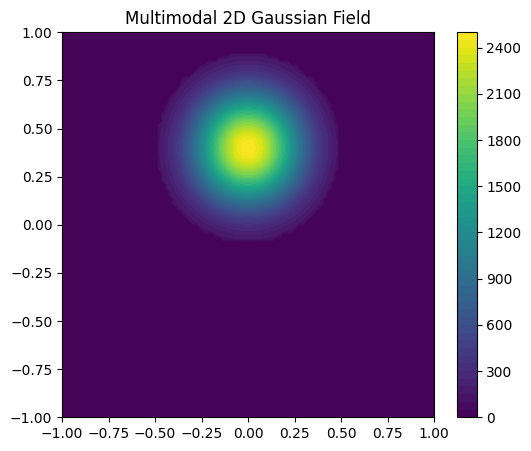

In [3]:
# creat 100 by 100 multimodal Gaussian field
means1 = [(0, 0.4)]
stds1  = [(0.2, 0.2)]
amps1  = [1]

density1, (X, Y), grid1, cell_area1 = multimodal_gaussian_2d(means1, stds1, N=100, amplitudes=amps1)
density1[density1<0.05] = 0
density1 /= cell_area1  # normalize to sum to be order one after accounting for cell area

plt.figure(figsize=(6,5))
plt.contourf(X, Y, density1, 50)
plt.colorbar()
plt.title("Multimodal 2D Gaussian Field")
plt.show()


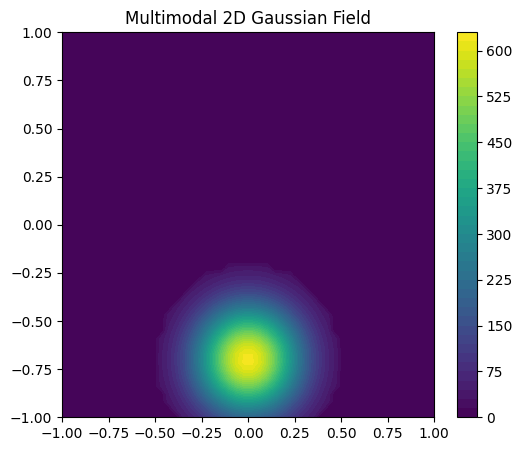

In [4]:
# creat 50 by 50 multimodal Gaussian field
means1 = [(0, -0.7)]
stds1  = [(0.2, 0.2)]
amps1  = [1]


density2, (X, Y), grid2, cell_area2 = multimodal_gaussian_2d(means1, stds1, N=50, amplitudes=amps1)
density2[density2<0.05] = 0
density2 /= cell_area2  # normalize to sum to be order one after accounting for cell area

plt.figure(figsize=(6,5))
plt.contourf(X, Y, density2, 50)
plt.colorbar()
plt.title("Multimodal 2D Gaussian Field")
plt.show()


## Epsilon?
This should be set to the maximum displament between two neighbouring pairs. So for this regular setting in a [-1, 1] (L=2) box,
epsilon ~ L/N where N=min(150, 200), is the number of grid points along one axis. 

Alternatively calculate a reasonable epsilon per grid, and then take the largest value. 

In [5]:
uot_class = DebiasedUOT(pykeops=True) # , cuda_device='cpu')
uot_class.parameters(epsilon=2/100, rho=2.0)
uot_class.densities(forecast_density=density1*cell_area1, forecast_points=grid1, observation_density=density2*cell_area2, observation_points=grid2)


Tolerances may be harder to meet and so set to a lower value here.

In [6]:
output = uot_class.sinkhorn_algorithm(sinkhorn_steps=1000, aprox='kl', tol=1e-10)
se = uot_class.sinkhorn_divergence(tol=1e-10)


Convergence in f, g updates below 1e-10 in 131 iterations
Convergence in f, g updates below 1e-10 in 183 iterations


In [7]:
output, se

((tensor(3.371695589393653e-09, device='cuda:0', dtype=torch.float64),
  tensor(6.676622810175559e-09, device='cuda:0', dtype=torch.float64),
  999),
 tensor(475.170555712379837, device='cuda:0', dtype=torch.float64))

vectors

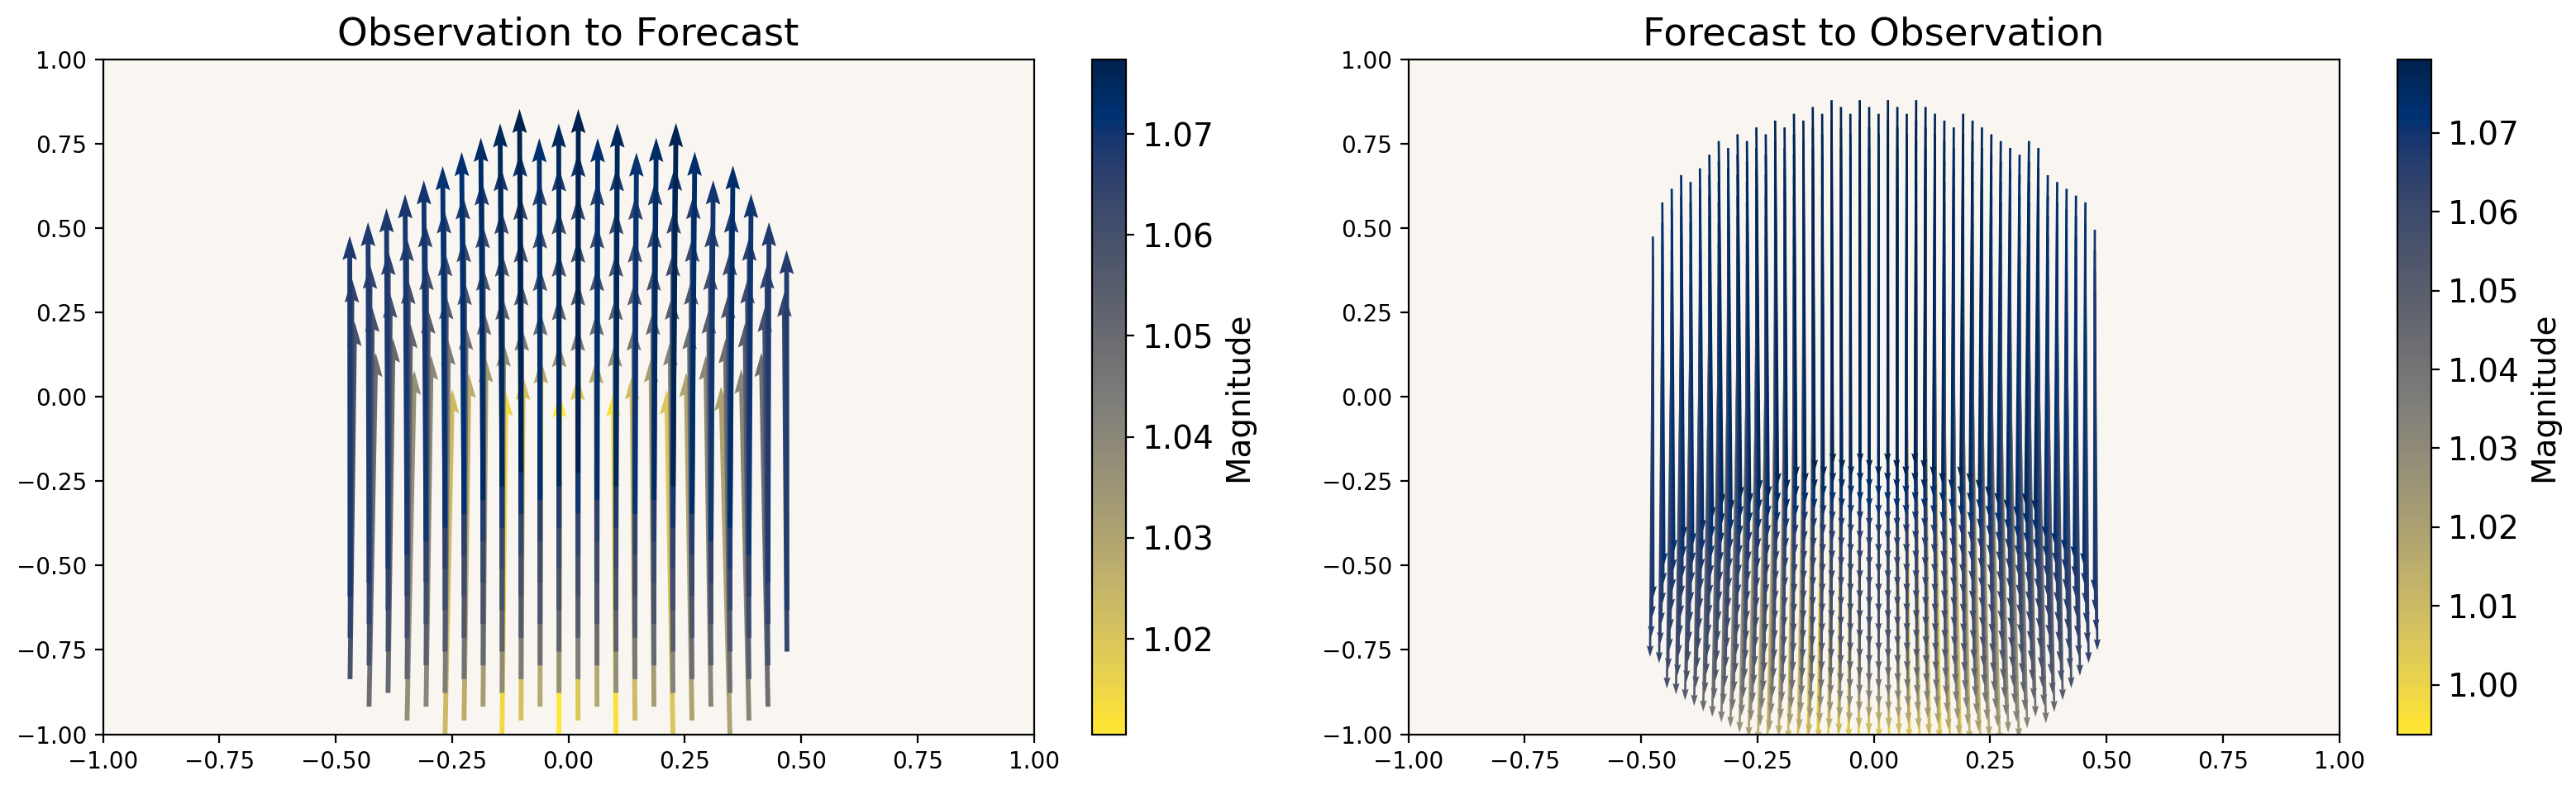

In [8]:

# Biased vector - Observation to forecast
V0 = uot_class.barycentre_map_of_points("target").cpu()
# Debiasing extra term for V0: V0 - u0 is the debiased vector
u0 = uot_class.debias_f.barycentre_map_of_points("target").cpu()


# Biased vector - Forecast to observation
V1 = uot_class.barycentre_map_of_points("source").cpu()
# Debiasing extra term for V1: V1 - u1 is the debiased vector
u1 = uot_class.debias_g.barycentre_map_of_points("source").cpu()

fig, axs = plt.subplots(1, 2, figsize=(16, 5), dpi=200)

plt.rcParams.update({"font.size": 14})

# First plot
ax = axs[0]
# ax.set(xlim=(0, 200))
v0 = (V0 - u0)  # Adjust vector field
step = 3
colors = torch.norm(v0[::step, :], dim=1).numpy()
colors[np.isnan(colors)] = 0
grid = (torch.tensor(grid2[0]), torch.tensor(grid2[1]))
X_flat = torch.cartesian_prod(*grid)
index = colors > 0
quiv = ax.quiver(
    X_flat[::step, 0][index],
    X_flat[::step, 1][index],
    -v0[::step, 0][index],
    -v0[::step, 1][index],
    colors[index],
    cmap="cividis_r",
    angles="xy",
    scale_units="xy",
    scale=1,
)
fig.colorbar(
    quiv, ax=ax, label="Magnitude"
)  # Attach colorbar to the correct subplot
ax.set_facecolor("#f9f6f1")  # Set background color for this subplot
ax.set_title("Observation to Forecast")
ax.set(xlim=(-1, 1), ylim=(-1, 1))

# Second plot
ax = axs[1]
# ax.set(xlim=(0, 200))
v0 = (V1 - u1)  # Adjust vector field
colors = torch.norm(v0[::step, :], dim=1).numpy()
colors[np.isnan(colors)] = 0
grid = (torch.tensor(grid1[0]), torch.tensor(grid1[1]))
X_flat = torch.cartesian_prod(*grid)
index = colors > 0
quiv = ax.quiver(
    X_flat[::step, 0][index],
    X_flat[::step, 1][index],
    -v0[::step, 0][index],
    -v0[::step, 1][index],
    colors[index],
    cmap="cividis_r",
    angles="xy",
    scale_units="xy",
    scale=1,
)
fig.colorbar(
    quiv, ax=ax, label="Magnitude"
)  # Attach colorbar to the correct subplot
ax.set_facecolor("#f9f6f1")  # Set background color for this subplot
ax.set_title("Forecast to Observation")

ax.set(xlim=(-1, 1), ylim=(-1, 1))

# plt.suptitle('C1C1 Transport Vectors', y=0.95)
plt.tight_layout()
plt.show()

Everything moves down since the whole guassian was shifted down.

#### We can even have regular grids with shape (N1,  N2) and (M1, M2) for all different intergers, and still use tensorisation.

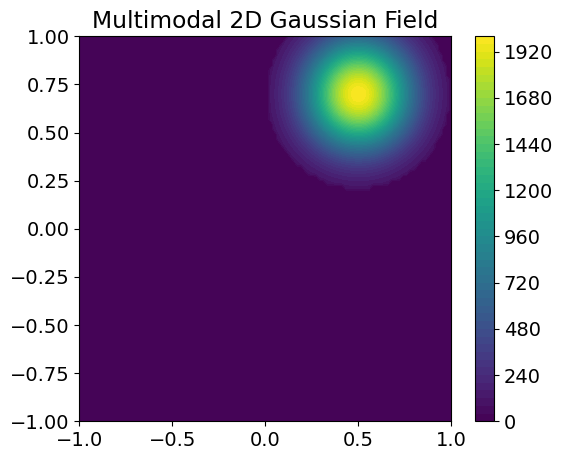

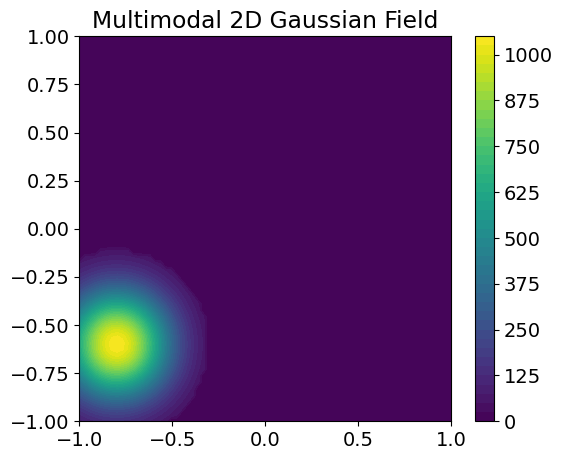

Convergence in f, g updates below 1e-10 in 725 iterations
Symmetric problem 1 not converged, psuedo residal: 1.521e-09 You may wish to increase convergence_repeats
Symmetric problem 1 not converged, psuedo residal: 2.343e-09 You may wish to increase convergence_repeats


((tensor(7.596900886142066e-11, device='cuda:0', dtype=torch.float64),
  tensor(9.962441982480641e-11, device='cuda:0', dtype=torch.float64),
  725),
 tensor(504.164115536506756, device='cuda:0', dtype=torch.float64))

In [9]:
# creat 100 by 100 multimodal Gaussian field
means1 = [(0.5, 0.7)]
stds1  = [(0.2, 0.2)]
amps1  = [1]

density1, (X, Y), grid1, cell_area1 = multimodal_gaussian_2d(means1, stds1, N=100, M =80, amplitudes=amps1)
density1[density1<0.05] = 0
density1 /= cell_area1  # normalize to sum to be order one after accounting for cell area

plt.figure(figsize=(6,5))
plt.contourf(X, Y, density1, 50)
plt.colorbar()
plt.title("Multimodal 2D Gaussian Field")
plt.show()

# creat 100 by 100 multimodal Gaussian field
means1 = [(-0.8, -0.6)]
stds1  = [(0.2, 0.2)]
amps1  = [1]

density2, (X, Y), grid2, cell_area2 = multimodal_gaussian_2d(means1, stds1, N=70, M=60, amplitudes=amps1)
density2[density2<0.05] = 0
density2 /= cell_area2  # normalize to sum to be order one after accounting for cell area

plt.figure(figsize=(6,5))
plt.contourf(X, Y, density2, 50)
plt.colorbar()
plt.title("Multimodal 2D Gaussian Field")
plt.show()


uot_class = DebiasedUOT(pykeops=True) # , cuda_device='cpu')
uot_class.parameters(epsilon=2/60, rho=2.0)
uot_class.densities(forecast_density=density1*cell_area1, forecast_points=grid1, observation_density=density2*cell_area2, observation_points=grid2)


output = uot_class.sinkhorn_algorithm(sinkhorn_steps=1000, aprox='kl', tol=1e-10)
se = uot_class.sinkhorn_divergence(tol=1e-10)

output, se


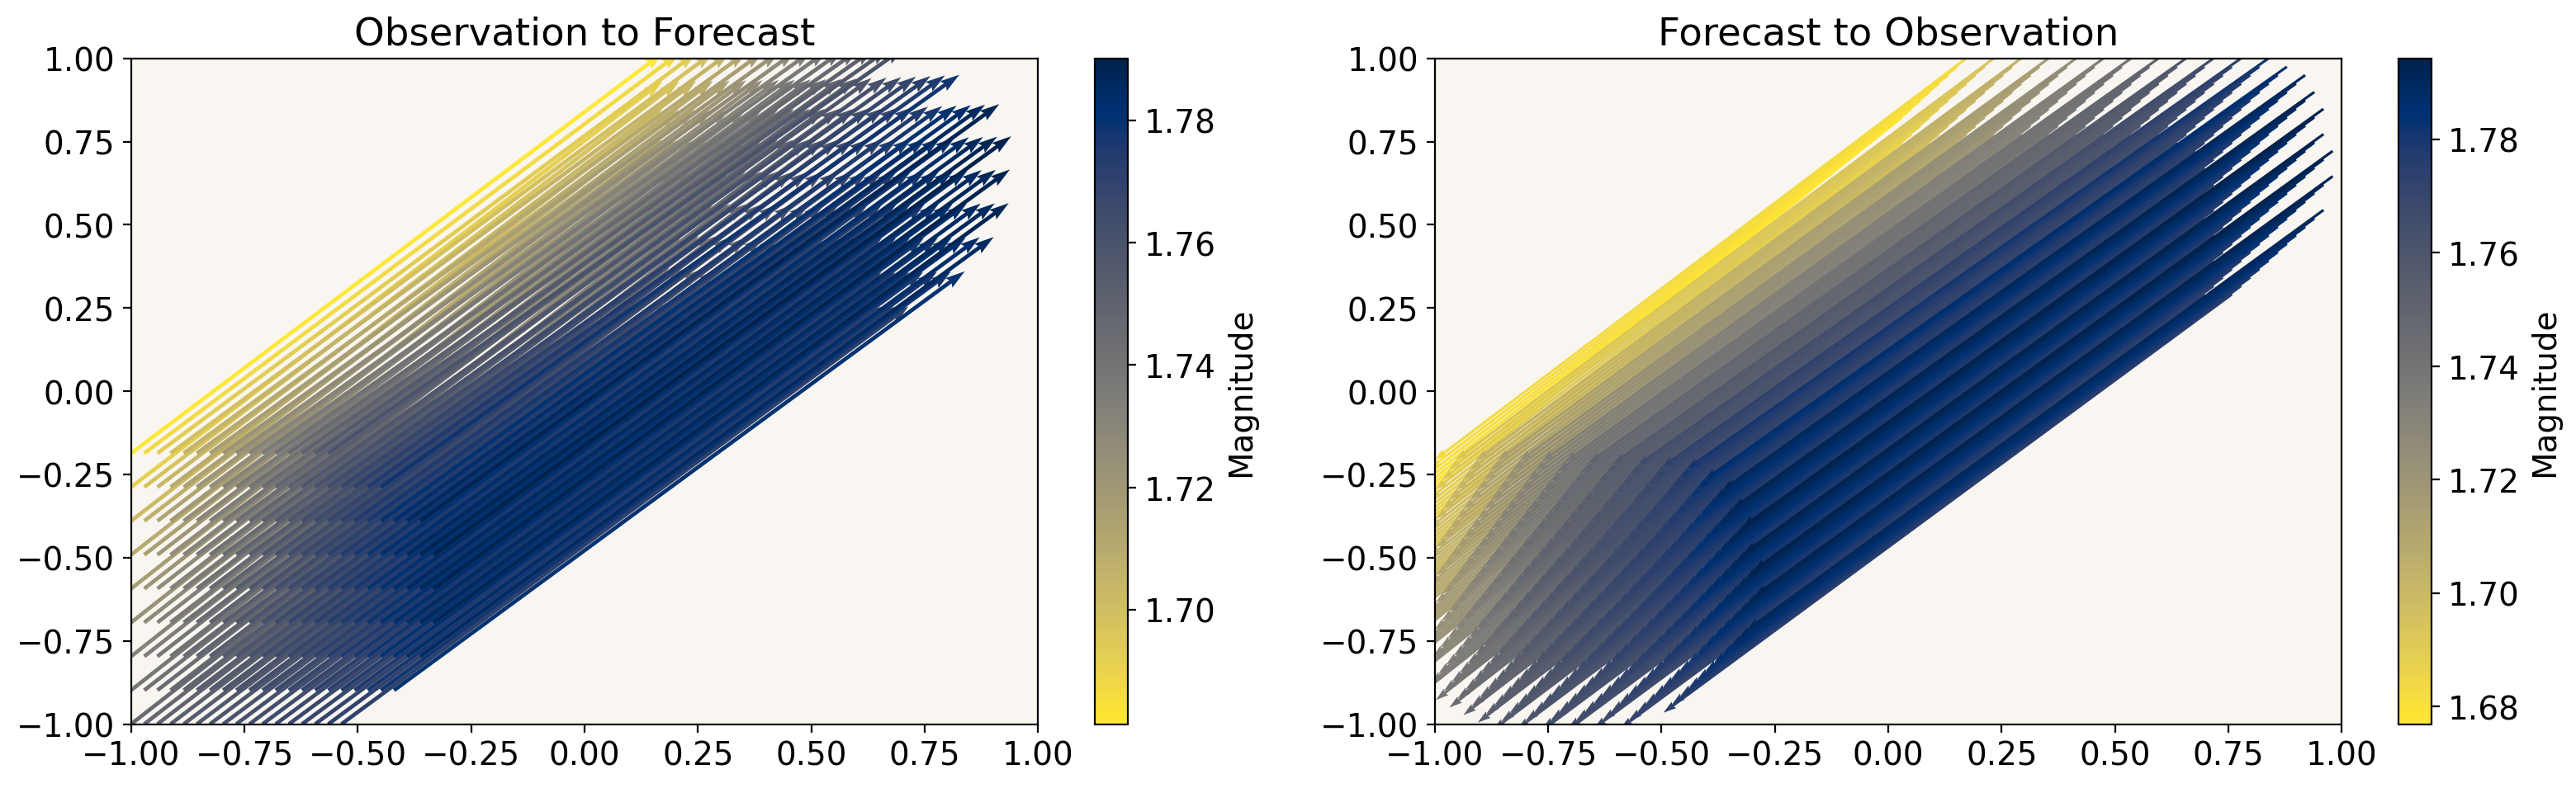

In [10]:

# Biased vector - Observation to forecast
V0 = uot_class.barycentre_map_of_points("target").cpu()
# Debiasing extra term for V0: V0 - u0 is the debiased vector
u0 = uot_class.debias_f.barycentre_map_of_points("target").cpu()


# Biased vector - Forecast to observation
V1 = uot_class.barycentre_map_of_points("source").cpu()
# Debiasing extra term for V1: V1 - u1 is the debiased vector
u1 = uot_class.debias_g.barycentre_map_of_points("source").cpu()

fig, axs = plt.subplots(1, 2, figsize=(16, 5), dpi=200)

plt.rcParams.update({"font.size": 14})

# First plot
ax = axs[0]
# ax.set(xlim=(0, 200))
v0 = (V0 - u0)  # Adjust vector field
step = 3
colors = torch.norm(v0[::step, :], dim=1).numpy()
colors[np.isnan(colors)] = 0
grid = (torch.tensor(grid2[0]), torch.tensor(grid2[1]))
X_flat = torch.cartesian_prod(*grid)
index = colors > 0
quiv = ax.quiver(
    X_flat[::step, 0][index],
    X_flat[::step, 1][index],
    -v0[::step, 0][index],
    -v0[::step, 1][index],
    colors[index],
    cmap="cividis_r",
    angles="xy",
    scale_units="xy",
    scale=1,
)
fig.colorbar(
    quiv, ax=ax, label="Magnitude"
)  # Attach colorbar to the correct subplot
ax.set_facecolor("#f9f6f1")  # Set background color for this subplot
ax.set_title("Observation to Forecast")
ax.set(xlim=(-1, 1), ylim=(-1, 1))

# Second plot
ax = axs[1]
# ax.set(xlim=(0, 200))
v0 = (V1 - u1)  # Adjust vector field
colors = torch.norm(v0[::step, :], dim=1).numpy()
colors[np.isnan(colors)] = 0
grid = (torch.tensor(grid1[0]), torch.tensor(grid1[1]))
X_flat = torch.cartesian_prod(*grid)
index = colors > 0
quiv = ax.quiver(
    X_flat[::step, 0][index],
    X_flat[::step, 1][index],
    -v0[::step, 0][index],
    -v0[::step, 1][index],
    colors[index],
    cmap="cividis_r",
    angles="xy",
    scale_units="xy",
    scale=1,
)
fig.colorbar(
    quiv, ax=ax, label="Magnitude"
)  # Attach colorbar to the correct subplot
ax.set_facecolor("#f9f6f1")  # Set background color for this subplot
ax.set_title("Forecast to Observation")

ax.set(xlim=(-1, 1), ylim=(-1, 1))

# plt.suptitle('C1C1 Transport Vectors', y=0.95)
plt.tight_layout()
plt.show()

## Irregular grids (currently point clouds)

The example I use is sampled randomly in the grid so we can approximate the areas of the cell as being equal. 
For true Lon-lat though over large areasa these will vary and should be taken into account. 

In [11]:

def multimodal_gaussian_2d_random(means, stds, N=100, M=None, domain=[-1, 1, -1, 1], amplitudes=None, seed=None):
    """
    Generate a multimodal 2D Gaussian field on N*M uniform random points in the domain.

    Parameters
    ----------
    means : list of (mx, my)
        Mean of each Gaussian mode.
    stds : list of (sx, sy)
        Standard deviations for each mode.
    N : int
        Number of points along x.
    M : int or None
        Number of points along y. Defaults to N if None.
    domain : [xmin, xmax, ymin, ymax]
        Spatial domain to sample points.
    amplitudes : list or None
        Optional amplitude per mode. Defaults to 1 for each mode.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    density : (N*M,) numpy array
        Gaussian field values at each random point.
    points : (N*M, 2) numpy array
        Randomly sampled points [[x0, y0], [x1, y1], ...].
    """

    if M is None:
        M = N
    
    if seed is not None:
        np.random.seed(seed)
    
    xmin, xmax, ymin, ymax = domain
    total_points = N * M
    cell_area = ((xmax - xmin) / N) * ((ymax - ymin) / M) # we approximate as random sampling.

    # uniformly random points in domain
    x_rand = np.random.uniform(xmin, xmax, total_points)
    y_rand = np.random.uniform(ymin, ymax, total_points)
    points = np.column_stack((x_rand, y_rand))

    # initialize density
    density = np.zeros(total_points)
    if amplitudes is None:
        amplitudes = [1.0] * len(means)
    
    # compute multimodal Gaussian values at each point
    for (mx, my), (sx, sy), A in zip(means, stds, amplitudes):
        density += A * np.exp(-(((x_rand - mx)**2) / (2 * sx**2) +
                                ((y_rand - my)**2) / (2 * sy**2)))

    return density, points, cell_area


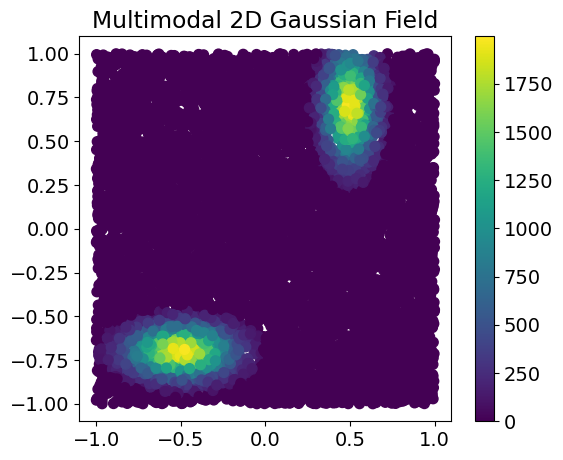

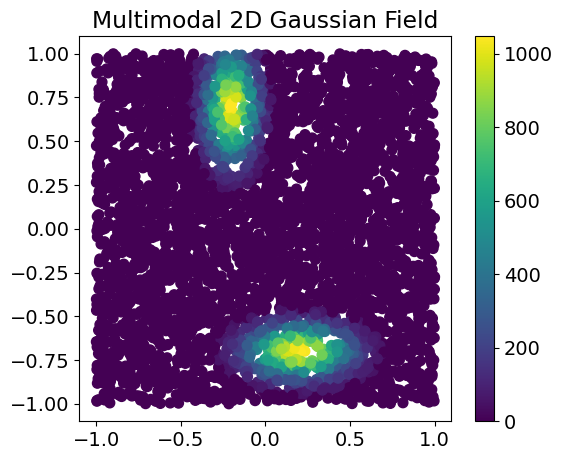

In [12]:
# creat 100 by 100 multimodal Gaussian field
means1 = [(0.5, 0.7), (-0.5, -0.7)]
stds1  = [(0.1, 0.2), (0.2, 0.1)]
amps1  = [1, 1]

density1, grid1, cell_area = multimodal_gaussian_2d_random(means1, stds1, N=100, M =80, amplitudes=amps1)
density1[density1<0.05] = 0
density1 /= cell_area  # normalize to sum to be order one after accounting for cell area

plt.figure(figsize=(6,5))
plt.scatter(grid1[:, 0], grid1[:, 1], c=density1, s=50)
plt.colorbar()
plt.title("Multimodal 2D Gaussian Field")
plt.show()

# creat 100 by 100 multimodal Gaussian field
means1 = [(-0.2, 0.7), (0.2, -0.7)]
stds1  = [(0.1, 0.2), (0.2, 0.1)]
amps1  = [1, 1]

density2, grid2, cell_area = multimodal_gaussian_2d_random(means1, stds1, N=70, M=60, amplitudes=amps1)
density2[density2<0.05] = 0
density2 /= cell_area  # normalize to sum to be order one after accounting for cell area

plt.figure(figsize=(6,5))
plt.scatter(grid2[:, 0], grid2[:, 1], c=density2, s=50)
plt.colorbar()
plt.title("Multimodal 2D Gaussian Field")
plt.show()


In [13]:

uot_class = DebiasedUOT(pykeops=True) # , cuda_device='cpu')
uot_class.parameters(epsilon=2/60, rho=2.0)
uot_class.densities(forecast_density=density1*cell_area, forecast_points=grid1, observation_density=density2*cell_area, observation_points=grid2)


output = uot_class.sinkhorn_algorithm(sinkhorn_steps=1000, aprox='kl', tol=1e-10)
se = uot_class.sinkhorn_divergence(tol=1e-10)

output, se


Convergence in f, g updates below 1e-10 in 601 iterations
Convergence in f, g updates below 1e-10 in 69 iterations
Convergence in f, g updates below 1e-10 in 77 iterations


((tensor(9.840905867974925e-11, device='cuda:0', dtype=torch.float64),
  tensor(9.679590462496890e-11, device='cuda:0', dtype=torch.float64),
  601),
 tensor(552.963893183595246, device='cuda:0', dtype=torch.float64))

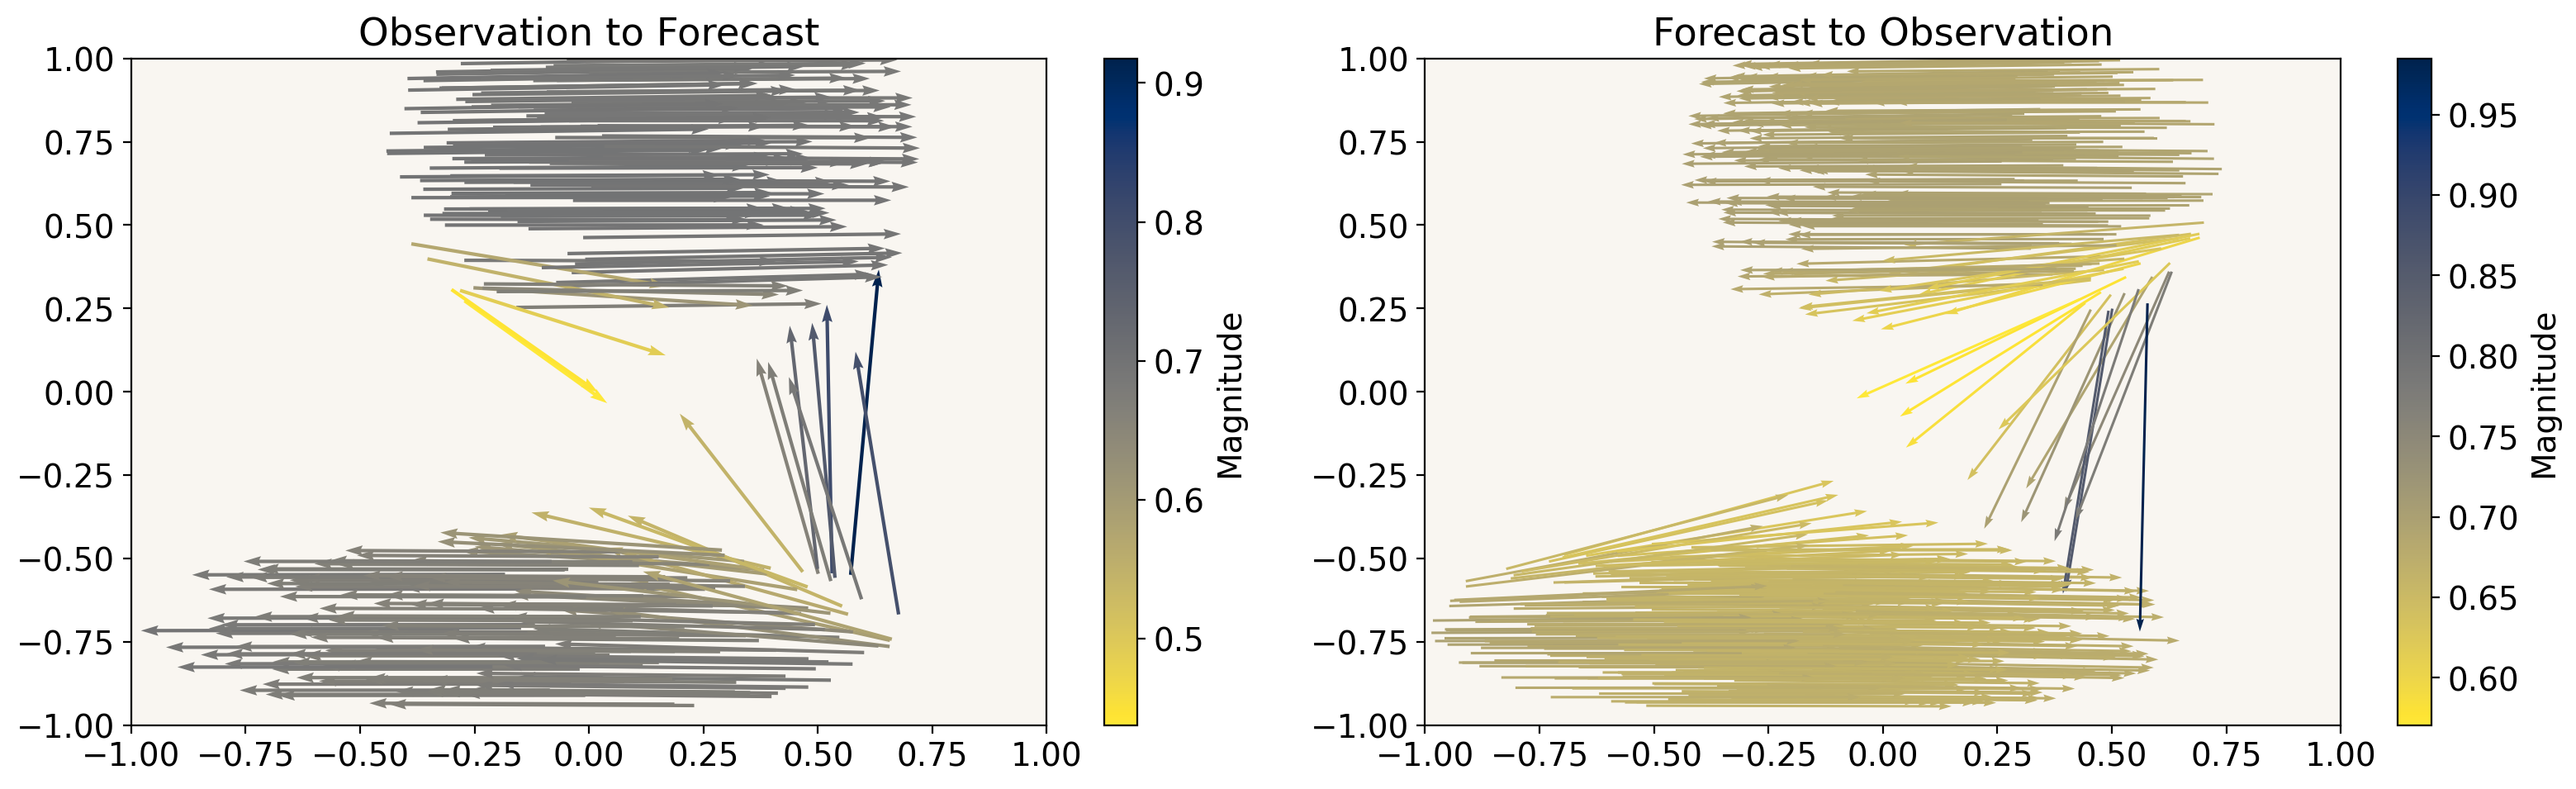

In [14]:

# Biased vector - Observation to forecast
V0 = uot_class.barycentre_map_of_points("target").cpu()
# Debiasing extra term for V0: V0 - u0 is the debiased vector
u0 = uot_class.debias_f.barycentre_map_of_points("target").cpu()


# Biased vector - Forecast to observation
V1 = uot_class.barycentre_map_of_points("source").cpu()
# Debiasing extra term for V1: V1 - u1 is the debiased vector
u1 = uot_class.debias_g.barycentre_map_of_points("source").cpu()

fig, axs = plt.subplots(1, 2, figsize=(16, 5), dpi=200)

plt.rcParams.update({"font.size": 14})

# First plot
ax = axs[0]
# ax.set(xlim=(0, 200))
v0 = (V0 - u0)  
step = 3
colors = torch.norm(v0[::step, :], dim=1).numpy()
colors[np.isnan(colors)] = 0
X_flat = grid2
index = colors > 0
quiv = ax.quiver(
    X_flat[::step, 0][index],
    X_flat[::step, 1][index],
    -v0[::step, 0][index],
    -v0[::step, 1][index],
    colors[index],
    cmap="cividis_r",
    angles="xy",
    scale_units="xy",
    scale=1,
)
fig.colorbar(
    quiv, ax=ax, label="Magnitude"
)  # Attach colorbar to the correct subplot
ax.set_facecolor("#f9f6f1")  # Set background color for this subplot
ax.set_title("Observation to Forecast")
ax.set(xlim=(-1, 1), ylim=(-1, 1))

# Second plot
ax = axs[1]
# ax.set(xlim=(0, 200))
v0 = (V1 - u1)  
colors = torch.norm(v0[::step, :], dim=1).numpy()
colors[np.isnan(colors)] = 0
X_flat = grid1
index = colors > 0
quiv = ax.quiver(
    X_flat[::step, 0][index],
    X_flat[::step, 1][index],
    -v0[::step, 0][index],
    -v0[::step, 1][index],
    colors[index],
    cmap="cividis_r",
    angles="xy",
    scale_units="xy",
    scale=1,
)
fig.colorbar(
    quiv, ax=ax, label="Magnitude"
)  # Attach colorbar to the correct subplot
ax.set_facecolor("#f9f6f1")  # Set background color for this subplot
ax.set_title("Forecast to Observation")

ax.set(xlim=(-1, 1), ylim=(-1, 1))

# plt.suptitle('C1C1 Transport Vectors', y=0.95)
plt.tight_layout()
plt.show()